-  Nate Diaz-Santana
-  Data Exploration and Analysis

# Predicting Sleep Quality from Lifestyle Factors

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from scipy.stats import skew, kurtosis, mode
from scipy.stats import pearsonr, spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

## Data

In [5]:
data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

### DESCRIPTIONS

- **Person ID**: An identifier for each individual.
- **Gender**: The gender of the person (Male/Female).
- **Age**: The age of the person in years.
- **Occupation**: The occupation or profession of the person.
- **Sleep Duration (hours)**: The number of hours the person sleeps per day.
- **Quality of Sleep (scale: 1-10)**: A subjective rating of the quality of sleep, ranging from 1 to 10.
- **Physical Activity Level (minutes/day)**: The number of minutes the person engages in physical activity daily.
- **Stress Level (scale: 1-10)**: A subjective rating of the stress level experienced by the person, ranging from 1 to 10.
- **BMI Category**: The BMI category of the person (e.g., Underweight, Normal, Overweight).
- **Blood Pressure (systolic/diastolic)**: The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.
- **Heart Rate (bpm)**: The resting heart rate of the person in beats per minute.
- **Daily Steps**: The number of steps the person takes per day.
- **Sleep Disorder**: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

In [7]:
data.shape # dataset shape

(374, 13)

In [8]:
data.info() # set info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
data = data.drop('Person ID', axis=1) # not needed for analysis

In [10]:
data.head() # sample data

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Univariate Analysis

In [12]:
# description
desc = data.describe().T # transform for column as rows

# skewn and kurtosis for numeric columns only
num_cols = data.select_dtypes(include='number').columns

desc['skew'] = data[num_cols].skew()
desc['kurtosis'] = data[num_cols].kurtosis()

# NaN for non-numeric columns
desc[['skew', 'kurtosis']] = desc[['skew', 'kurtosis']].fillna('N/A')

# no print() for fancy table
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0,0.257222,-0.909780
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.8,8.5,0.037554,-1.286506
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.0,9.0,-0.207448,-0.748276
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.0,90.0,0.074487,-1.266068
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.0,8.0,0.154330,-1.327307
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.0,86.0,1.224824,2.286455
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.0,10000.0,0.178277,-0.394031


### Histograms

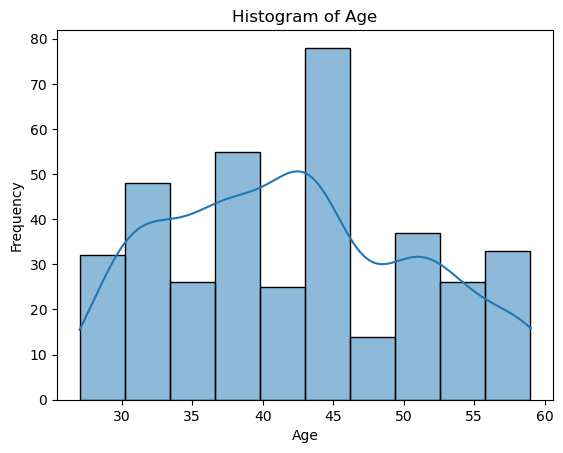

In [14]:
sb.histplot(data['Age'], kde=True) # kde for better distribution view
plt.title(f'Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

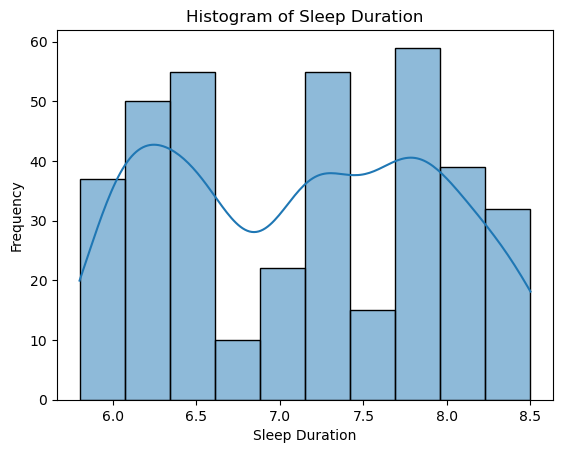

In [15]:
sb.histplot(data['Sleep Duration'], kde=True)
plt.title(f'Histogram of Sleep Duration')
plt.xlabel('Sleep Duration')
plt.ylabel('Frequency')
plt.show()

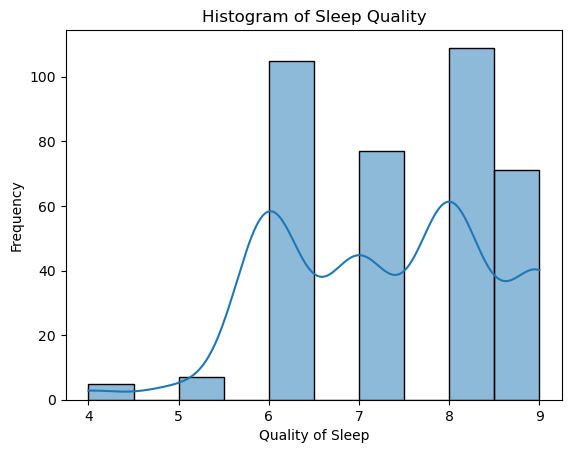

In [16]:
sb.histplot(data['Quality of Sleep'], kde=True)
plt.title(f'Histogram of Sleep Quality')
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')
plt.show()

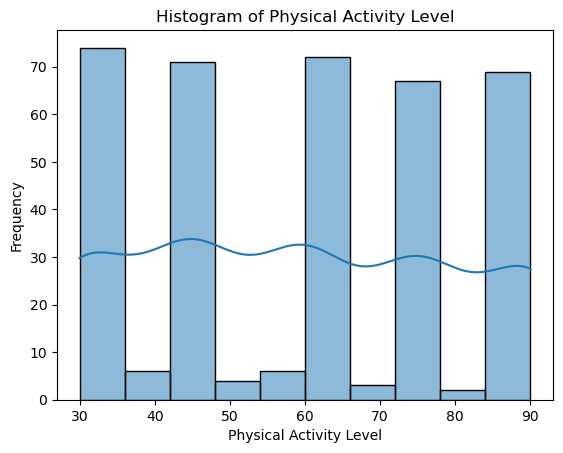

In [17]:
sb.histplot(data['Physical Activity Level'], kde=True)
plt.title(f'Histogram of Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Frequency')
plt.show()

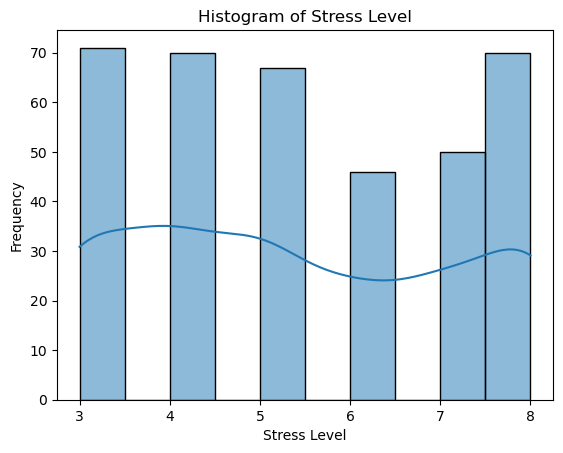

In [18]:
sb.histplot(data['Stress Level'], kde=True)
plt.title(f'Histogram of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

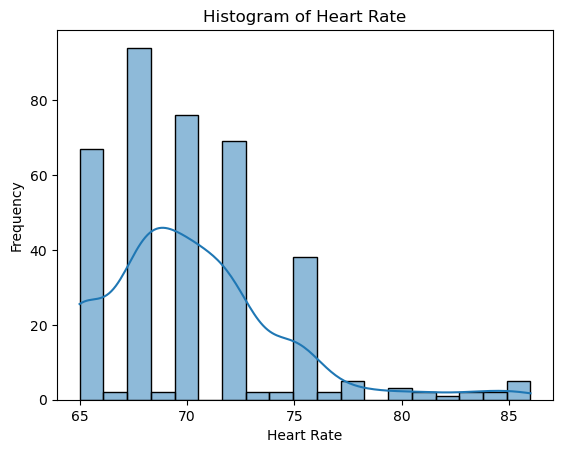

In [19]:
sb.histplot(data['Heart Rate'], kde=True)
plt.title(f'Histogram of Heart Rate')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

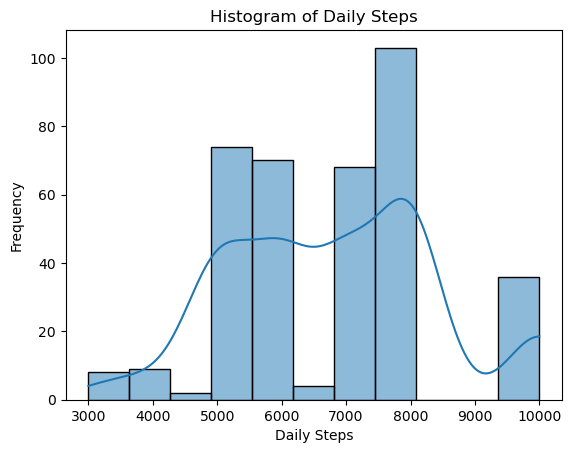

In [20]:
sb.histplot(data['Daily Steps'], kde=True)
plt.title(f'Histogram of Daily Steps')
plt.xlabel('Daily Steps')
plt.ylabel('Frequency')
plt.show()

### Boxplots

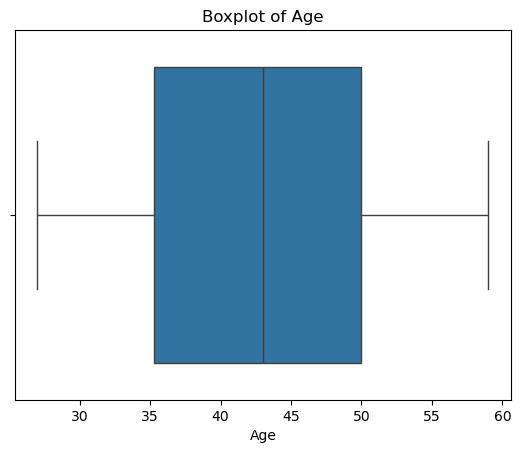

In [22]:
sb.boxplot(x=data['Age'])
plt.title(f'Boxplot of Age')
plt.xlabel('Age')
plt.show()

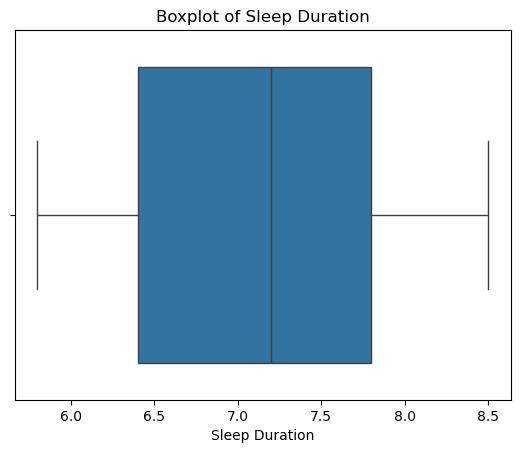

In [23]:
sb.boxplot(x=data['Sleep Duration'])
plt.title(f'Boxplot of Sleep Duration')
plt.xlabel('Sleep Duration')
plt.show()

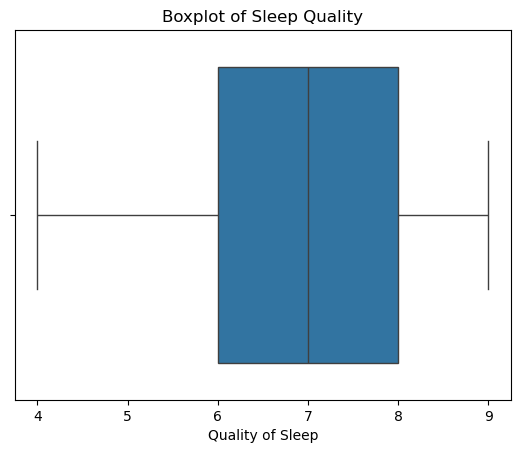

In [24]:
sb.boxplot(x=data['Quality of Sleep'])
plt.title(f'Boxplot of Sleep Quality')
plt.xlabel('Quality of Sleep')
plt.show()

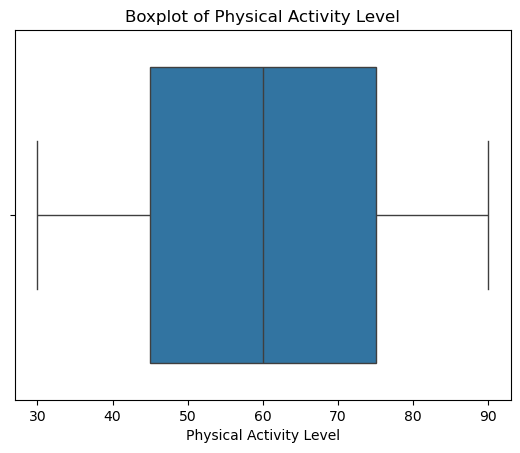

In [25]:
sb.boxplot(x=data['Physical Activity Level'])
plt.title(f'Boxplot of Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.show()

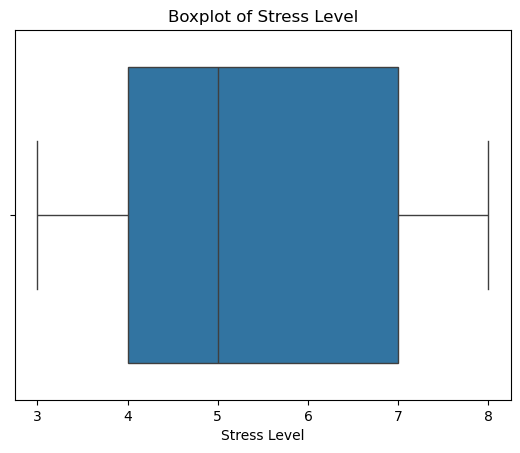

In [26]:
sb.boxplot(x=data['Stress Level'])
plt.title(f'Boxplot of Stress Level')
plt.xlabel('Stress Level')
plt.show()

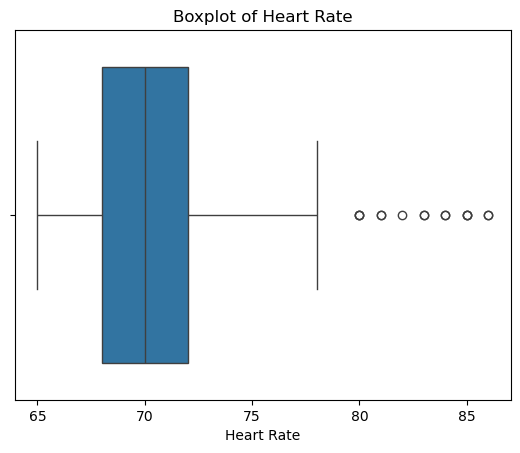

In [27]:
sb.boxplot(x=data['Heart Rate'])
plt.title(f'Boxplot of Heart Rate')
plt.xlabel('Heart Rate')
plt.show()

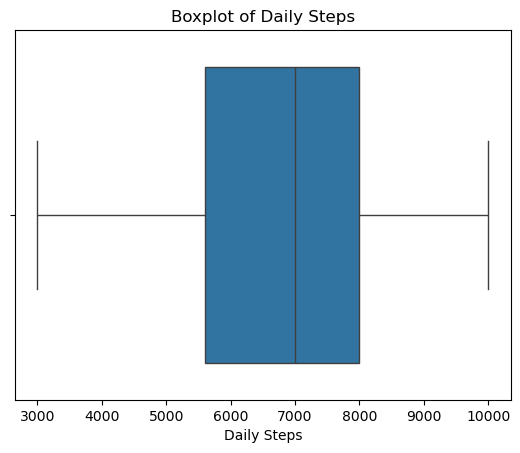

In [28]:
sb.boxplot(x=data['Daily Steps'])
plt.title(f'Boxplot of Daily Steps')
plt.xlabel('Daily Steps')
plt.show()

## Bivariate Analysis

In [30]:
# pearson correlation matrix 
corr_matrix = data[num_cols].corr()

corr_matrix

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Age,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


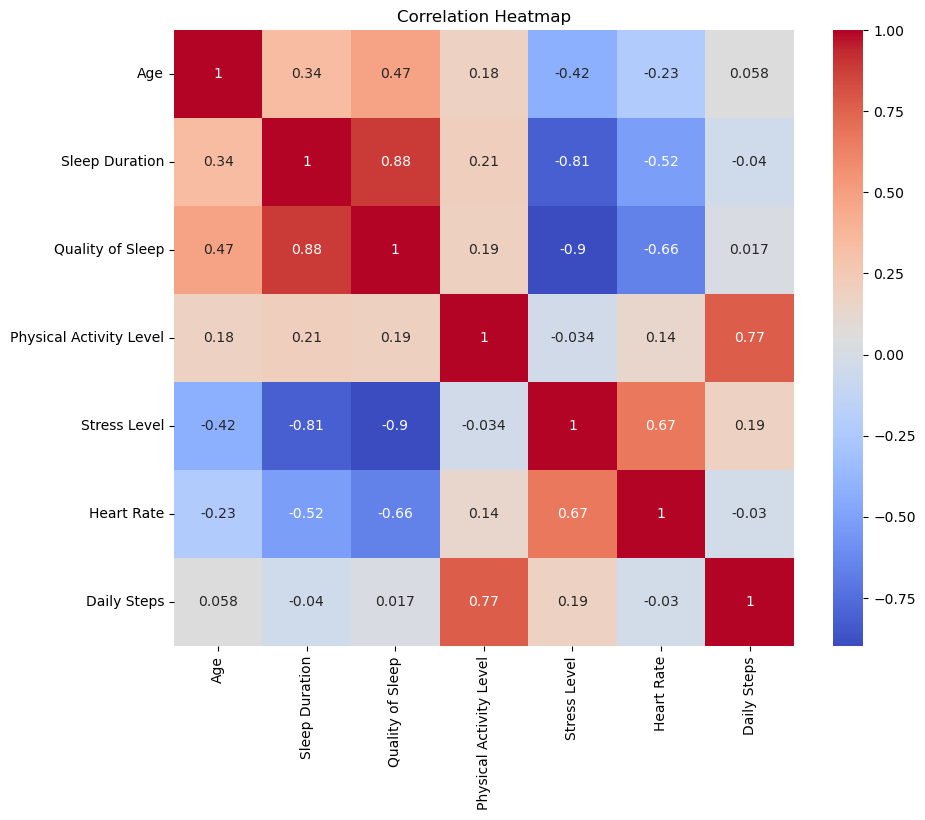

In [31]:
# correlation heatmap
plt.figure(figsize=(10,8))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show() # actually very cool graph

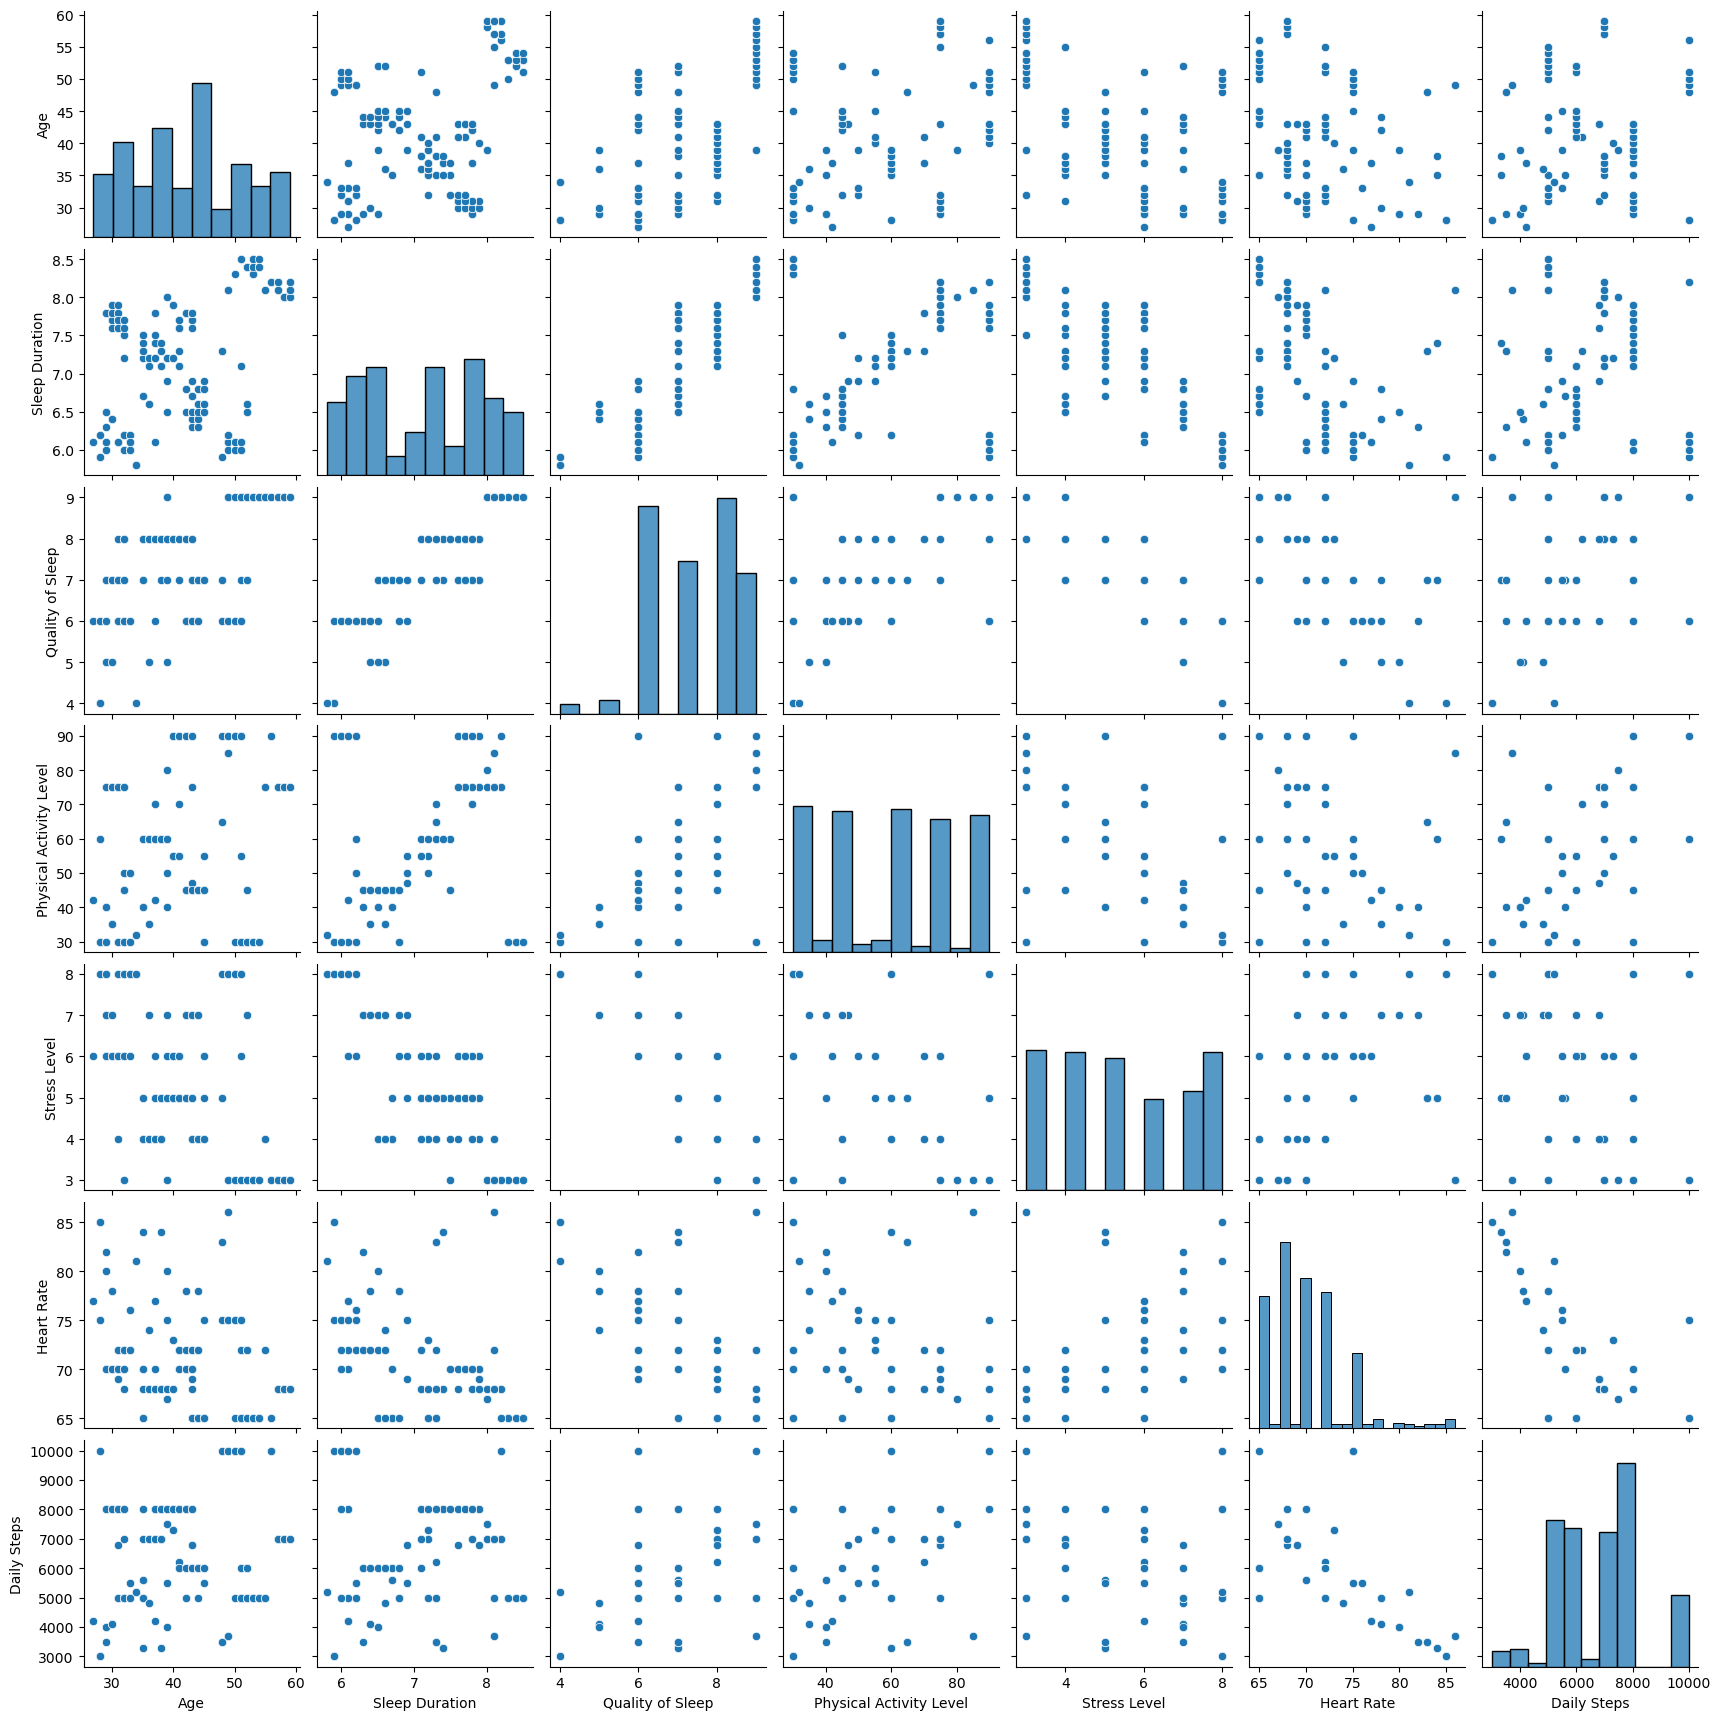

In [32]:
sb.pairplot(data[num_cols])

## Test Statistics

We're testing the relationship between **physical activity levels** and **sleep quality**.

- **Null Hypothesis (H₀):** There is no significant relationship between physical activity levels and sleep quality.
- **Alternative Hypothesis (H₁):** There is a significant relationship between physical activity levels and sleep quality.


**Assumptions:**  
- Both variables are approximately normally distributed.  
- The relationship between physical activity and sleep quality is linear.  
- Data are independent.

**However:**
- **Physical Activity Level** seems to be possible uniform, as shown in the histograms
- **Sleep Quality** also shows a slight left skew in the histograms

Since the histograms show non-normal distributions, I'll be using **Spearman correlation** due to it's unnecessity of normally distributed variables.

### Statistical Test Results

In [37]:
# no need to drop null since we saw there is none in these columns earlier
x = data['Physical Activity Level']
y = data['Quality of Sleep']

# correlation
corr, p_val = spearmanr(x, y) # spearman bc vars are not normal distr.
print("Spearman correlation:", corr)
print("P-value:", p_val)

Spearman correlation: 0.17846632741434998
P-value: 0.0005249322396509238


- **Spearman correlation coefficient:** 0.1785  
- **p-value:** 0.0005

Since the **p-value is less than 0.05**, we reject the null hypothesis, suggesting that there is a statistically significant, positive relationship between Physical Activity Level and Quality of Sleep.

## Regression and Classification

### Regression Analysis

**Intercept:**
- An intercept of around **6.6** suggests that when the physical acvitiy level is 0, the sleep quality score is around 6.6, according to the linear regression.

**Coefficient:**
- A coefficient of **0.011** suggests that for a one level increase in physical activity, there should be a 0.011 point increase in sleep quality score, according to the linear regression. 0.011 is a very small increase, suggesting that physical activity level may be only weakly tied to sleep quality.

**R-Squared:**
- An R-squared value of **0.037** suggests that only around 3.7% of the variance in sleep quality is due to physical activity levels. Also suggesting that other factors likely influence sleep quality more than just physical activity level.

In [42]:
# model data
X = data[['Physical Activity Level']]  # predictor
y = data['Quality of Sleep']

# fit model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# coefficients
print("Intercept:", lin_reg.intercept_)
print("Coefficient:", lin_reg.coef_[0])

# R-squared
r_squared = lin_reg.score(X, y)
print("R-squared:", r_squared)

Intercept: 6.656981707840874
Coefficient: 0.011083996442273515
R-squared: 0.03720904232832434


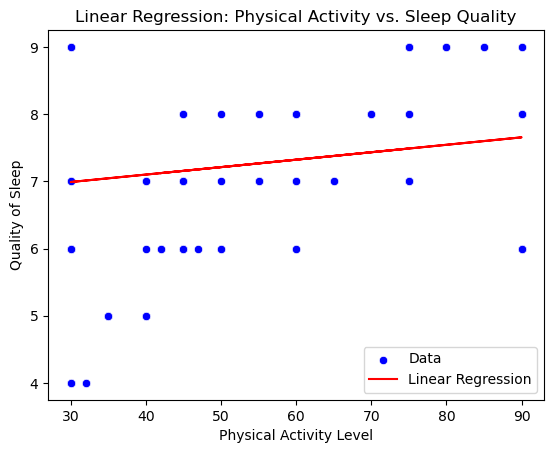

In [43]:
# data scatter plot
sb.scatterplot(x='Physical Activity Level', y='Quality of Sleep', data=data, color='blue', label='Data')

# regression line
x_line = data['Physical Activity Level']
y_line = lin_reg.intercept_ + lin_reg.coef_[0] * x_line
plt.plot(x_line, y_line, color='red', label='Linear Regression')

plt.xlabel('Physical Activity Level')
plt.ylabel('Quality of Sleep')
plt.title('Linear Regression: Physical Activity vs. Sleep Quality')
plt.legend()
plt.show() # visual of the linear regression

### Classification Model

**Logistic Regression:**
<br>
**Sleep Duration** added to features to help improve accuracy and model performance as link between physical activity and sleep quality is significant but weak.
- The regression performed well in predicting sleep quality scores of 6, 8, and 9.
- Sleep scores of 7 had high precision but lower recall, suggesting misclassifications.
- Poor performance on scores of 4 and 5 can likely be attributed to lack of samples as seen in the support value of 2 for both.

In [46]:
# features and target
X = data[['Physical Activity Level', 'Sleep Duration']]
y_class = data['Quality of Sleep'] 

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.3, random_state=42)

#  pipeline scales and fits to model
pipeline = make_pipeline(
    StandardScaler(), # scales data for better results
    LogisticRegression(max_iter=1000) # increased iterations for better results
)

# fits to scaler and then model
pipeline.fit(X_train, y_train)

# prediction
y_pred = pipeline.predict(X_test)

# eval
print(classification_report(y_test, y_pred, zero_division=0)) # zero division is to prevent some error pop-up thing

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         2
           6       0.86      1.00      0.93        37
           7       0.86      0.30      0.44        20
           8       0.70      0.97      0.81        29
           9       1.00      1.00      1.00        23

    accuracy                           0.83       113
   macro avg       0.57      0.54      0.53       113
weighted avg       0.82      0.83      0.79       113



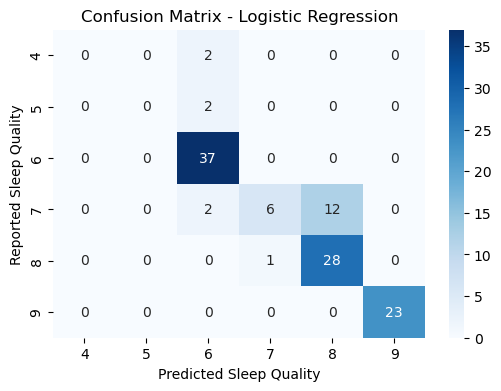

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=pipeline.classes_,
           yticklabels=pipeline.classes_)

plt.xlabel('Predicted Sleep Quality')
plt.ylabel('Reported Sleep Quality')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

## Advanced Analysis Techniques  

### K-means Clustering

**Cluster Interpretation:**
- Silhouette score of **0.701** indicates well defined and separated clusters.
- Cluster 0 (**Purple**): Moderate-high physical activity (67.4) has the highest sleep quality (7.95)
- Cluster 1 (**Blue**): Highest physical activity (89.6) has the second highest sleep quality (7.18)
- Cluster 2 (**Green**): Low physical activity (30.3) has slightly worse sleep quality (7.14)
- Cluster 3 (**Yellow**): Low-moderate physical activity (45.5) has the worst sleep quality (6.53)


E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


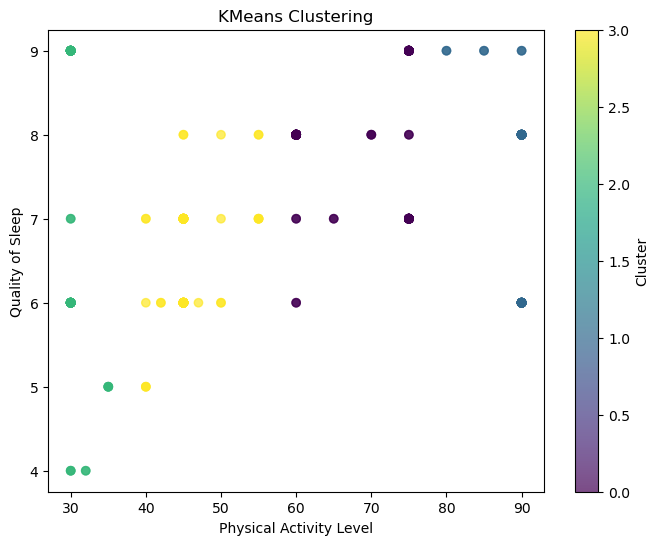

In [51]:
# features
X_clust = data[['Physical Activity Level', 'Quality of Sleep']]

# clusters
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_clust)

# Add cluster labels to the dataframe
data['Cluster'] = clusters

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(data['Physical Activity Level'], data['Quality of Sleep'], c=data['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Physical Activity Level')
plt.ylabel('Quality of Sleep')
plt.title('KMeans Clustering')
plt.colorbar(label='Cluster')
plt.show()

In [52]:
# centers: [activity, sleep score]
print(kmeans.cluster_centers_)

# close to 1 is better
print("Silhouette Score:", silhouette_score(X, data['Cluster']))

[[67.35915493  7.95070423]
 [89.57746479  7.18309859]
 [30.32432432  7.13513514]
 [45.52873563  6.52873563]]
Silhouette Score: 0.7169292260262127


### Machine Learning approach to Regression or Classification  

**Random Forest Classification**
<br>
The increase in performance and accuracy when compared to the previous logistic regression classifier can likely be attributed to the random forest's flexibility and ability to better handle imbalanced classes more effectively.
- As part 5 did, this classification model included the aditional feature of **Sleep Duration** to accurately compare performance to the previous logistic regression classification model.
- This model greatly increased in accuracy with **91%**, compared to the 83% in the previous model.
- Sleep scores of 4 and 5 had perfect (**1.00**) precision and recall, likely due to the low sample size shown by the support values.
- Scores 6, 8, and 9 showed great precision (**1.00, 0.93, 1.00**) like in the previous model, with very high f1-scores (**0.90, 0.95, 1.00**).
- Score 7 has slightly lower precision (**0.69**) than other scores but recall (**0.90**) significantly improved from the previous model (**0.30**).

In [55]:
# features and target
X_class = data[['Physical Activity Level', 'Sleep Duration']]
y_class = data['Quality of Sleep']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

# data scaler and model
pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# fit scaler and model
pipeline.fit(X_train, y_train)

# prediction
y_pred = pipeline.predict(X_test)

# eval
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      0.81      0.90        37
           7       0.69      0.90      0.78        20
           8       0.93      0.97      0.95        29
           9       1.00      1.00      1.00        23

    accuracy                           0.91       113
   macro avg       0.94      0.95      0.94       113
weighted avg       0.93      0.91      0.91       113



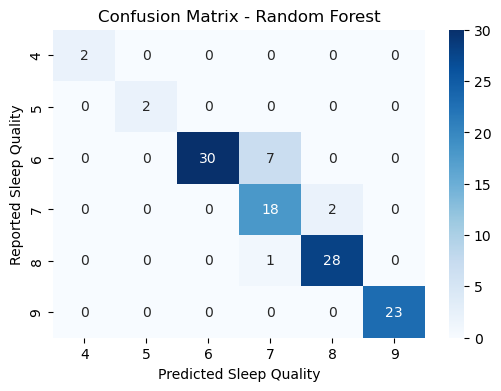

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=pipeline.classes_,
           yticklabels=pipeline.classes_)

plt.xlabel('Predicted Sleep Quality')
plt.ylabel('Reported Sleep Quality')
plt.title('Confusion Matrix - Random Forest')

plt.show()